# Israeli Actors Graph — Community Detection (Step 3, Period C only)

Runs and compares three community-detection algorithms on Period C
(>1990) — all available in `networkx>=3.5`, no extra dependencies:

- **Louvain** (`nx.community.louvain_communities`) — modularity
  optimization via local moves + aggregation.
- **Greedy modularity** (`nx.community.greedy_modularity_communities`) —
  greedy agglomerative merging by modularity gain.
- **Label propagation** (`nx.community.asyn_lpa_communities`) — each node
  adopts its neighbors' most common label, iterated to convergence.

Communities are then characterized (for Louvain, as the primary result)
using data already collected — dominant genres and active-year range from
each member's film credits (restricted to Period C), plus the top-degree
actors as representative members. No separate actor-page lookups.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../src"))
import graph_build
import communities

if sys.stdout.encoding and sys.stdout.encoding.lower() != "utf-8":
    sys.stdout.reconfigure(encoding="utf-8")

plt.rcParams["font.family"] = "Arial"  # better Hebrew glyph coverage than the default

## Rebuild Period C

In [2]:
cast_edges = graph_build.load_cast_edges("../data/processed/cast_edges.csv")
G = graph_build.build_full_graph(cast_edges)
H = graph_build.period_subgraph(G, "C")
print(f"Period C: {H.number_of_nodes()} actors, {H.number_of_edges()} collaborations")

Period C: 1106 actors, 4731 collaborations


## Run all three algorithms

In [3]:
results = communities.run_algorithms(H, seed=42)
comparison = communities.compare_algorithms(H, results)
comparison

,n_communities,modularity,largest_community,median_community,n_singletons
algorithm,,,,,
louvain,68,0.693632,135,3,16
greedy_modularity,64,0.649382,223,3,16
label_propagation,198,0.612443,75,3,16


**Modularity** measures how much more densely connected each detected
community is compared to a random graph with the same degree sequence
(higher = stronger community structure, typically >0.3 is considered
meaningful). All three algorithms find substantial structure here; Louvain
and greedy modularity land on similar community counts, while label
propagation tends to fragment into more, smaller groups (a known tendency
of the algorithm on graphs with many locally-dense pockets).

## How much do the algorithms agree?

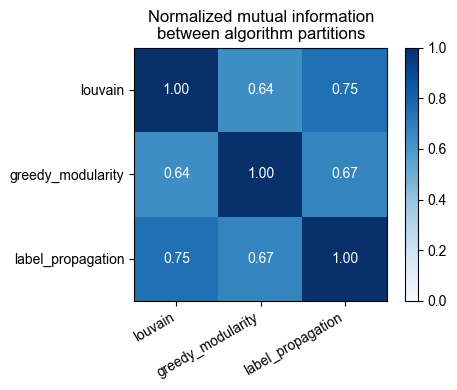

In [4]:
nmi = communities.pairwise_nmi(H, results)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(nmi.values.astype(float), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(nmi)))
ax.set_yticks(range(len(nmi)))
ax.set_xticklabels(nmi.columns, rotation=30, ha="right")
ax.set_yticklabels(nmi.index)
for i in range(len(nmi)):
    for j in range(len(nmi)):
        ax.text(j, i, f"{nmi.values[i, j]:.2f}", ha="center", va="center",
                 color="white" if nmi.values[i, j] > 0.5 else "black")
ax.set_title("Normalized mutual information\nbetween algorithm partitions")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

NMI of 1.0 means two partitions are identical; 0 means no relationship.
Louvain and label propagation agree more with each other than either does
with greedy modularity, but all pairwise scores are well above 0 — the
three algorithms are finding broadly the same underlying structure, just
disagreeing on the finer boundaries.

## Community size distribution (Louvain)

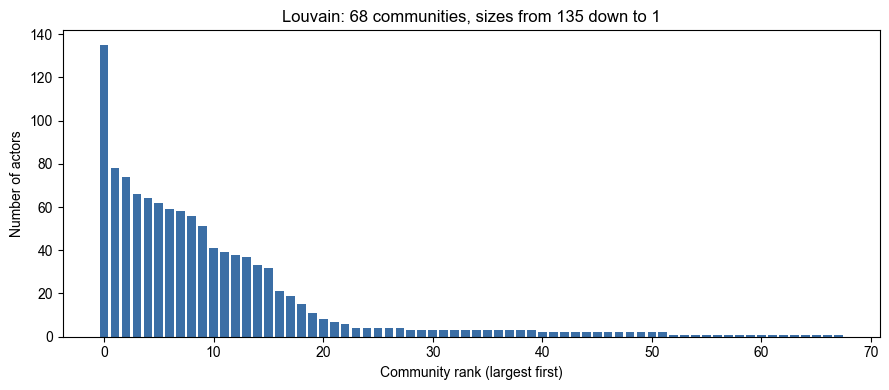

In [5]:
louvain_sizes = sorted((len(c) for c in results["louvain"]), reverse=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(louvain_sizes)), louvain_sizes, color="#3b6ea5")
ax.set_xlabel("Community rank (largest first)")
ax.set_ylabel("Number of actors")
ax.set_title(f"Louvain: {len(louvain_sizes)} communities, sizes from {louvain_sizes[0]} down to {louvain_sizes[-1]}")
plt.tight_layout()
plt.show()

## Characterizing the largest communities

In [6]:
char = communities.characterize_communities(H, results["louvain"], period="C", top_n=5, min_size=5)
print(f"{len(char)} of {len(results['louvain'])} Louvain communities have >=5 members; "
      f"showing the 15 largest for illustration (the rest are small pairs/trios with little internal signal).")
char.head(15)

23 of 68 Louvain communities have >=5 members; showing the 15 largest for illustration (the rest are small pairs/trios with little internal signal).


,size,top_actors,top_genres,year_range
0,135,"משה איבגי, דאנה איבגי, אלון אבוטבול, יעל אבקסי...","דרמה, קומדיה, קומדיית פשע",1991-2026
1,78,"ליאור אשכנזי, קובי פרג', צחי גראד, אביב אלוש, ...","דרמה, קומדיה, קומדיה,רומנטיקה",1993-2026
2,74,"שלומי קוריאט, אורי גבריאל, אוולין הגואל, יגאל ...","קומדיה, דרמה, פשע,קומדיה",1994-2026
3,66,"טלי שרון, אסי דיין, עומר ברנע, טינקרבל, שרה פו...","דרמה, דרמה, מתח, קומדיה",1991-2024
4,64,"יוסי מרשק, אושרי כהן, לבנה פינקלשטיין, חנן סבי...","דרמה, קומדיה, דרמה,קומדיה",1996-2026
5,62,"אורי פפר, אליאנה תדהר, ג'וי ריגר, אלישע בנאי, ...","דרמה, דרמה,מלחמה, קומדיה,רומנטיקה",1994-2026
6,59,"דרור קרן, ריקי בליך, תיקי דיין, איתי טיראן, עי...","דרמה, תיעודי, קומדיה רומנטית",1991-2024
7,58,"חיים זנאתי, יגאל נאור, זאב רווח, אלברט אילוז, ...","דרמה, דרמה,קומדיה, קומדיה",1992-2026
8,56,"אריה צ'רנר, שי אביבי, אפרת בן צור, ציון ברוך, ...","דרמה, קומדיה, דרמה, הרפתקה",1994-2025
9,51,"אקי אבני, עוז זהבי, גילה אלמגור, מיכאל אלוני, ...","דרמה, דרמה,מתח, דרמה, קומדיה",1991-2023


Each row is one community: its size, the actors with the most
collaborations *within* that community (a proxy for who anchors it), the
genres its members' Period C films skew toward, and the span of years those
films were made in.

**Coverage note against the assignment's community-characterization
checklist:**

| Requirement | Status |
|---|---|
| Community sizes | Covered for all 68 (size-distribution chart above); table shows the top 15 for readability |
| Central/anchor actors per community | Covered, for communities with >=5 members |
| Dominant genres | Covered, from each community's Period C film credits |
| Active periods | Covered (`year_range`) |
| Cinematic styles | **Weak** — the only signal available is the raw Wikipedia `genre` field; there's no separate style dimension (e.g. arthouse vs. mainstream) distinct from genre in this dataset |
| Demographic characteristics | **Not covered** — by design. Actor demographics (age, gender, birthplace) live on each actor's own Wikipedia page, and per an earlier project decision we deliberately don't visit those pages (only film pages), to keep the scrape fast. This is a known limitation to flag explicitly in the report, not an oversight. |

## Visualizing the largest communities

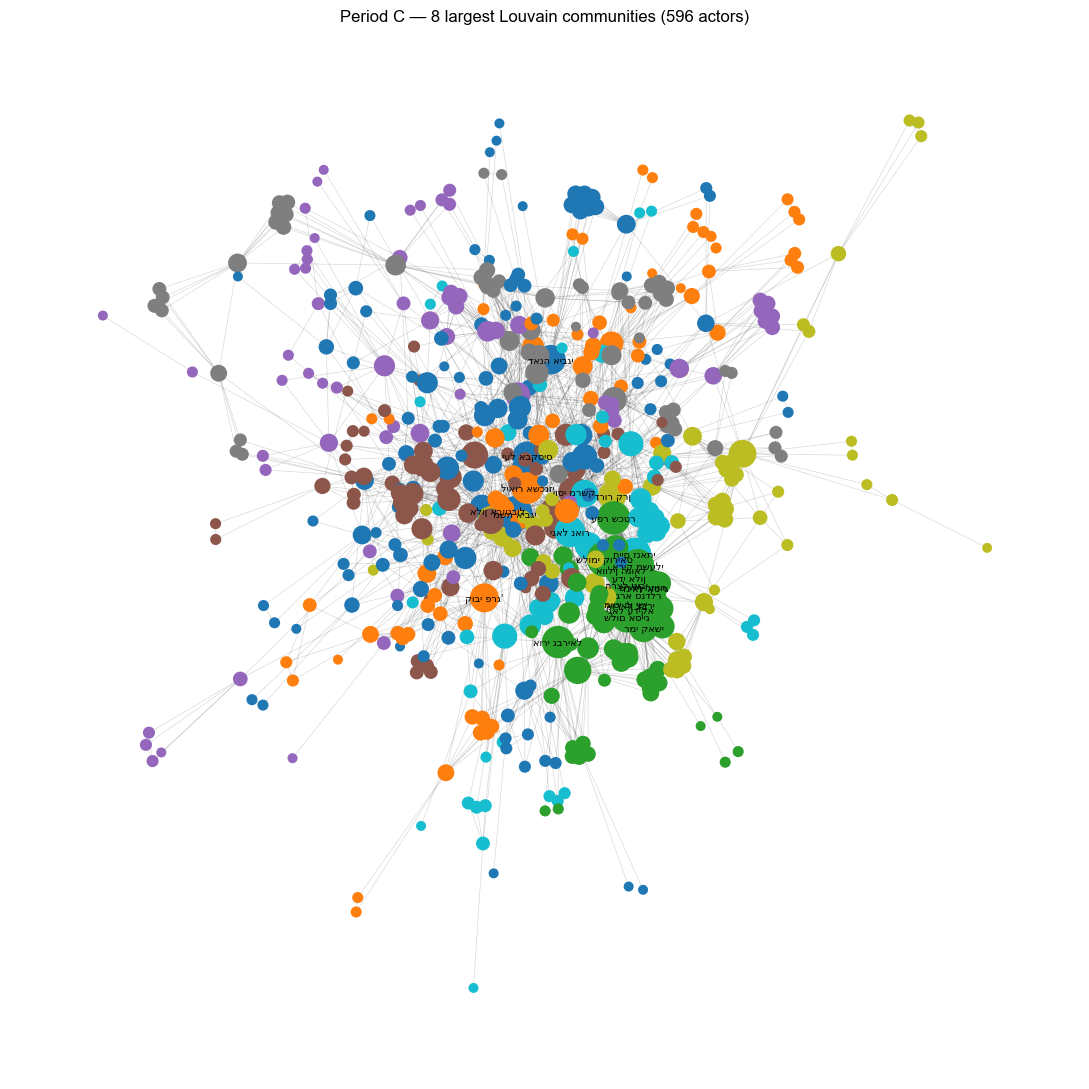

In [7]:
import itertools

louvain_by_size = sorted(results["louvain"], key=len, reverse=True)
top_communities = louvain_by_size[:8]  # keep the picture legible
shown_nodes = set().union(*top_communities)
sub = H.subgraph(shown_nodes)

palette = plt.cm.tab10(np.linspace(0, 1, len(top_communities)))
node_color = {}
for color, community in zip(palette, top_communities):
    for n in community:
        node_color[n] = color

degrees = dict(sub.degree())
sizes = [40 + 12 * degrees[n] for n in sub.nodes]
colors = [node_color[n] for n in sub.nodes]

fig, ax = plt.subplots(figsize=(11, 11))
pos = nx.spring_layout(sub, seed=42, k=0.5 / np.sqrt(max(sub.number_of_nodes(), 1)))
nx.draw_networkx_edges(sub, pos, ax=ax, alpha=0.15, width=0.5)
nx.draw_networkx_nodes(sub, pos, ax=ax, node_size=sizes, node_color=colors, linewidths=0)

top_labeled = sorted(degrees, key=degrees.get, reverse=True)[:25]
labels = {n: sub.nodes[n].get("display_name", n) for n in top_labeled}
nx.draw_networkx_labels(sub, pos, labels=labels, ax=ax, font_size=7)
ax.set_title(f"Period C — {len(top_communities)} largest Louvain communities ({sub.number_of_nodes()} actors)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Save community assignments

In [8]:
assignment_rows = []
for algo_name, community_list in results.items():
    for i, community in enumerate(community_list):
        for node in community:
            assignment_rows.append({
                "actor_id": node,
                "display_name": H.nodes[node].get("display_name", node),
                "algorithm": algo_name,
                "community_id": i,
                "community_size": len(community),
            })

community_assignments = pd.DataFrame(assignment_rows)
try:
    community_assignments.to_csv("../data/processed/community_assignments.csv", index=False, encoding="utf-8-sig")
    print("Saved community_assignments.csv to data/processed/")
except PermissionError:
    print("Could not write community_assignments.csv (likely locked by another program) -- skipping save.")

Saved community_assignments.csv to data/processed/


## Next steps

`05_centrality_analysis.ipynb`: degree / betweenness / closeness /
eigenvector centrality, and who bridges the communities found here.